In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("/content/credit_card_fraud_10k.csv")

print(df.head())
print("\nShape:", df.shape)

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


In [4]:
print(df.isnull().sum())

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
print(df.describe())

       transaction_id        amount  transaction_hour  foreign_transaction  \
count     10000.00000  10000.000000      10000.000000         10000.000000   
mean       5000.50000    175.949849         11.593300             0.097800   
std        2886.89568    175.392827          6.922708             0.297059   
min           1.00000      0.000000          0.000000             0.000000   
25%        2500.75000     50.905000          6.000000             0.000000   
50%        5000.50000    122.095000         12.000000             0.000000   
75%        7500.25000    242.480000         18.000000             0.000000   
max       10000.00000   1471.040000         23.000000             1.000000   

       location_mismatch  device_trust_score  velocity_last_24h  \
count       10000.000000        10000.000000       10000.000000   
mean            0.085700           61.798900           2.008900   
std             0.279935           21.487053           1.432559   
min             0.000000     

In [7]:
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    9849
1     151
Name: count, dtype: int64
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


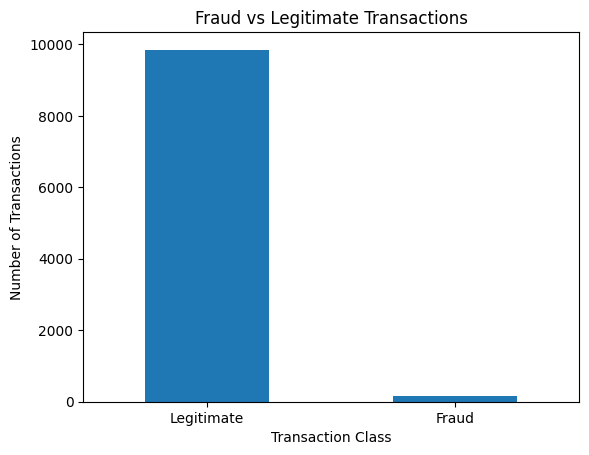

In [8]:
df["is_fraud"].value_counts().plot(kind="bar")

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.title("Fraud vs Legitimate Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)

plt.show()

In [9]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age'],
      dtype='object')

Target:
is_fraud


In [10]:
X = X.drop(columns=["transaction_id"])

print(X.head())

   amount  transaction_hour merchant_category  foreign_transaction  \
0   84.47                22       Electronics                    0   
1  541.82                 3            Travel                    1   
2  237.01                17           Grocery                    0   
3  164.33                 4           Grocery                    0   
4   30.53                15              Food                    0   

   location_mismatch  device_trust_score  velocity_last_24h  cardholder_age  
0                  0                  66                  3              40  
1                  0                  87                  1              64  
2                  0                  49                  1              61  
3                  1                  72                  3              34  
4                  0                  79                  0              44  


In [11]:
print(X.select_dtypes(include=["object"]).columns)

Index(['merchant_category'], dtype='object')


In [12]:
label_encoders = {}

for column in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column].astype(str))
    label_encoders[column] = le

print(X.head())

   amount  transaction_hour  merchant_category  foreign_transaction  \
0   84.47                22                  1                    0   
1  541.82                 3                  4                    1   
2  237.01                17                  3                    0   
3  164.33                 4                  3                    0   
4   30.53                15                  2                    0   

   location_mismatch  device_trust_score  velocity_last_24h  cardholder_age  
0                  0                  66                  3              40  
1                  0                  87                  1              64  
2                  0                  49                  1              61  
3                  1                  72                  3              34  
4                  0                  79                  0              44  


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


Training data: (8000, 8)
Testing data: (2000, 8)

Training target distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

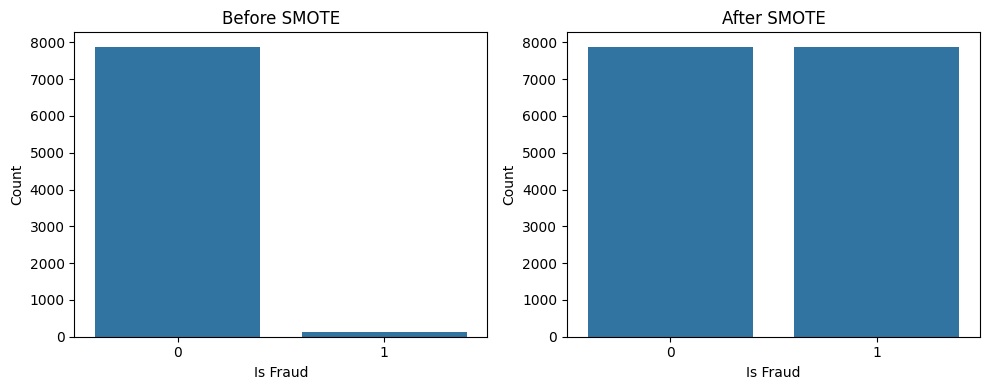

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Is Fraud")
axes[0].set_ylabel("Count")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Is Fraud")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [26]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [27]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[7.70676462e-03 3.00533213e-02 2.12073530e-04 1.12889305e-01
 3.98006436e-04 7.54040778e-02 5.36511252e-05 2.48706695e-02
 5.30380930e-05 1.12611358e-03]


In [28]:
threshold = 0.5

y_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1970
           1       0.32      0.87      0.47        30

    accuracy                           0.97      2000
   macro avg       0.66      0.92      0.73      2000
weighted avg       0.99      0.97      0.98      2000



In [29]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9705
Precision: 0.32098765432098764
Recall   : 0.8666666666666667
F1 Score : 0.46846846846846846
ROC-AUC  : 0.9892724196277496


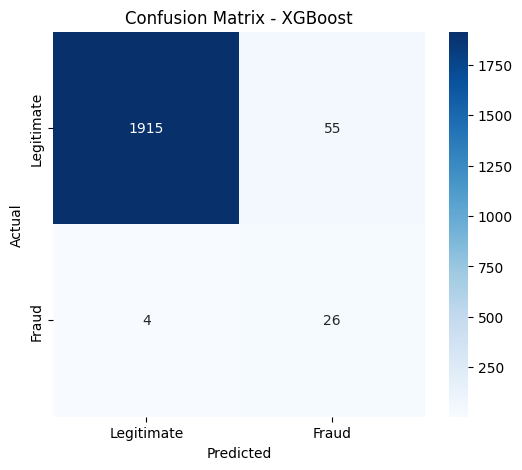

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

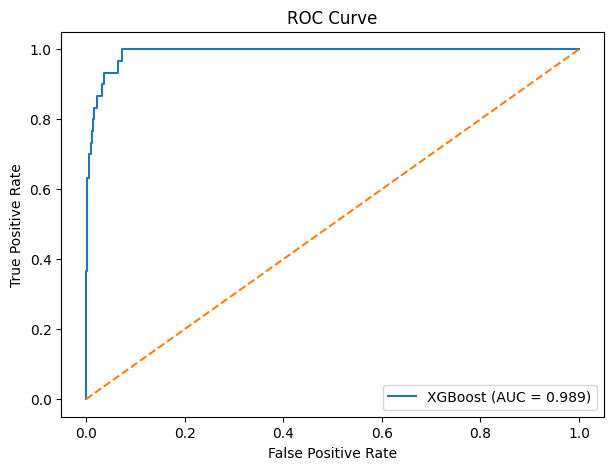

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

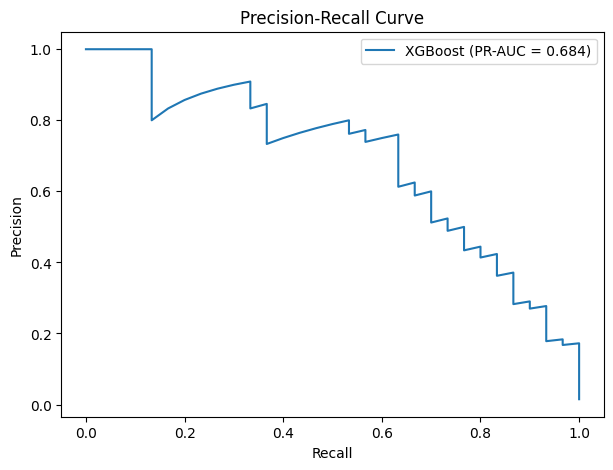

PR-AUC: 0.6841852988957049


In [33]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(recall_values, precision_values)

plt.figure(figsize=(7,5))

plt.plot(
    recall_values,
    precision_values,
    label=f"XGBoost (PR-AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("PR-AUC:", pr_auc)

In [34]:
thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds_to_test:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.1,0.142180,1.000000,0.248963
1,0.2,0.176829,0.966667,0.298969
2,0.3,0.212121,0.933333,0.345679
3,0.4,0.266667,0.933333,0.414815
4,0.5,0.320988,0.866667,0.468468
5,0.6,0.366197,0.866667,0.514851
6,0.7,0.416667,0.833333,0.555556
7,0.8,0.488889,0.733333,0.586667
8,0.9,0.583333,0.700000,0.636364


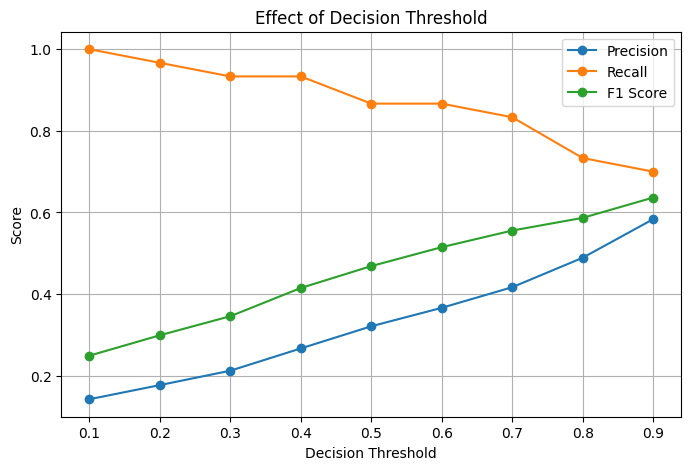

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Effect of Decision Threshold")
plt.legend()
plt.grid()
plt.show()

In [36]:
best_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold = best_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1 Score:", best_row["F1 Score"])

Best Threshold: 0.9
Precision: 0.5833333333333334
Recall: 0.7
F1 Score: 0.6363636363636364


In [37]:
y_pred_tuned = (
    y_prob >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      1970
       Fraud       0.58      0.70      0.64        30

    accuracy                           0.99      2000
   macro avg       0.79      0.85      0.82      2000
weighted avg       0.99      0.99      0.99      2000



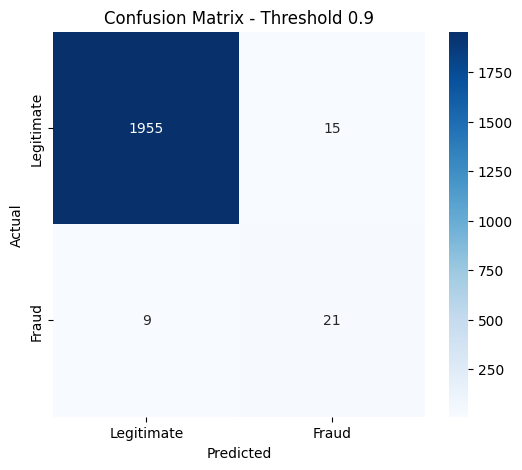

In [38]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - Threshold {best_threshold}")
plt.show()

In [39]:
fp_cost = 10
fn_cost = 100

threshold_costs = []

for threshold in np.arange(0.05, 0.96, 0.05):

    predictions = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test, predictions)

    tn, fp, fn, tp = cm.ravel()

    total_cost = (fp * fp_cost) + (fn * fn_cost)

    threshold_costs.append({
        "Threshold": round(threshold, 2),
        "False Positives": fp,
        "False Negatives": fn,
        "Total Cost": total_cost
    })

cost_df = pd.DataFrame(threshold_costs)

cost_df

,Threshold,False Positives,False Negatives,Total Cost
0,0.05,243,0,2430
1,0.10,181,0,1810
2,0.15,149,0,1490
3,0.20,135,1,1450
4,0.25,116,2,1360
5,0.30,104,2,1240
6,0.35,88,2,1080
7,0.40,77,2,970
8,0.45,67,3,970
9,0.50,55,4,950


In [40]:
best_cost_row = cost_df.loc[
    cost_df["Total Cost"].idxmin()
]

print("Cost-optimized threshold:",
      best_cost_row["Threshold"])

print("False Positives:",
      best_cost_row["False Positives"])

print("False Negatives:",
      best_cost_row["False Negatives"])

print("Total Cost:",
      best_cost_row["Total Cost"])

Cost-optimized threshold: 0.6
False Positives: 45.0
False Negatives: 4.0
Total Cost: 850.0


In [42]:
# Get feature names directly from the processed training data
feature_names = X_train.columns

# Get XGBoost feature importance
importance = xgb_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
5,device_trust_score,0.259571
1,transaction_hour,0.242763
3,foreign_transaction,0.146347
4,location_mismatch,0.128404
6,velocity_last_24h,0.100061
0,amount,0.047893
2,merchant_category,0.047254
7,cardholder_age,0.027707


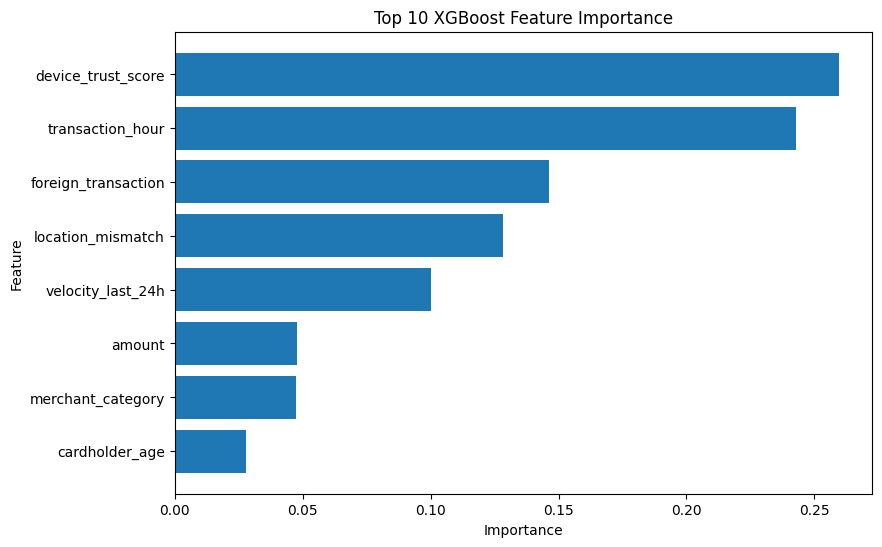

In [43]:
top_features = feature_importance.head(10)

plt.figure(figsize=(9,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Feature Importance")

plt.show()

In [44]:
default_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

comparison = pd.DataFrame({
    "Default Threshold (0.5)": default_metrics,
    "Tuned Threshold": tuned_metrics
})

comparison

,Default Threshold (0.5),Tuned Threshold
Accuracy,0.970500,0.988000
Precision,0.320988,0.583333
Recall,0.866667,0.700000
F1 Score,0.468468,0.636364
ROC-AUC,0.989272,0.989272


In [45]:
print("===== FINAL XGBOOST FRAUD DETECTION RESULTS =====")

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", pr_auc)

print("\nBest Threshold:", best_threshold)

print("\nMetrics at Tuned Threshold:")
print("Precision:",
      precision_score(y_test, y_pred_tuned, zero_division=0))
print("Recall:",
      recall_score(y_test, y_pred_tuned, zero_division=0))
print("F1 Score:",
      f1_score(y_test, y_pred_tuned, zero_division=0))

print("\nTop 10 Important Features:")
print(feature_importance.head(10))

===== FINAL XGBOOST FRAUD DETECTION RESULTS =====

ROC-AUC: 0.9892724196277496
PR-AUC: 0.6841852988957049

Best Threshold: 0.9

Metrics at Tuned Threshold:
Precision: 0.5833333333333334
Recall: 0.7
F1 Score: 0.6363636363636364

Top 10 Important Features:
               Feature  Importance
5   device_trust_score    0.259571
1     transaction_hour    0.242763
3  foreign_transaction    0.146347
4    location_mismatch    0.128404
6    velocity_last_24h    0.100061
0               amount    0.047893
2    merchant_category    0.047254
7       cardholder_age    0.027707
